# Predicting House Values using Tensorflow

In this notebook, we will consider a simple idea of trying to predict the median house value within a district.
In order to achieve this we will be using a simple method just based on the median income of a household (a group of people residing within a home). 

The approach is as follows:
* We take the data of median house values from some source (in our case we use a standard dataset from California).
* We will be considering the median house value from the data based on the median income of a household.
* We will then fit a line which best correlates the house value with the income.
* We will plot and consider the difference.

As is apparent, just basing the house value on the income is a simplification. However, this simple model
can be improved by considering  other features such as closeness to the sea or other aspects that influence the
house price.

In this notebook we will be carrying out this exercise using the Tensorflow package. In the next notebook, we will be doing
the same using another package, viz., PyTorch. These two are the most popular AI packages that are used by Google and Facebook
for all the AI related works and is used by hundreds of companies. This exercise takes you through the fundamental linear regression model from a number of different angles. First we consider an analytic analysis and then we continue to consider how to solve the same problem using numerical methods. This lab also serves and an introduction to the Tensorflow toolkit which will be useful for a variety of machine learning tasks in the future and is used by Google to solve massive machine learning problems on their clusters.

The fitting of a line to data is termed `linear regression'. We will be studying this and other similar algorithms in detail in the later modules of the
course.


In [1]:
# Jupyter's extra stack frames can push TensorFlow's import chain past Python's default recursion limit — raise it before importing tf.
import sys
sys.setrecursionlimit(3000)

In [2]:
# import relevant third-party libraries
import numpy as np 

# tensorflow package is not included in Anaconda by default, you may want to run the notebook file on Google Colab (https://colab.research.google.com/)
import tensorflow as tf

from sklearn import datasets as ds

%matplotlib inline
import matplotlib.pyplot as plt

In [3]:
# load california housing data
california = ds.fetch_california_housing()

# extract attribute (median income of a household) and target (median house value)
# california.data is a 2D NumPy array where rows = houses, columns = features like income, house age, rooms, etc.
# feature_names is just a list of strings, e.g. ['MedInc', 'HouseAge', 'AveRooms', ...]. Calling .index('MedInc') finds the position of 'MedInc' in that list — say it's index 0. 
# So this whole expression evaluates to a plain integer (the column number).
# california.data[:, 0] - so all rows and column # 
x_raw = california.data[:,california.feature_names.index('MedInc')]     # a 1D array, (20640,)  of each households median income
# california.target is the thing you're trying to predict so the full target array (what you're trying to predict)
# it is already pre-labelled as this is a Supervised learning example
y_raw = california.target

```python
print(california.data.shape)    # (20640, 8)  -> 20640 districts, 8 features each
print(california.target.shape)  # (20640,)    -> 20640 target values, one per district
print(california.data[0])       # features for district 0
print(california.target[0])     # house value for district 0
```

## California Housing Dataset
A description of the dataset used is provided here.

Data Set Characteristics:  
    :Number of Instances: 20640 

    :Number of Attributes: 8 numeric, predictive attributes
    
    :Target Variable: the median house value for California districts, in hundreds of thousands of dollars ($100,000)

    :Attribute Information (in order):
        - MedInc     median income in block group
        - HouseAge       median house age in block group
        - AveRooms    average number of rooms per household
        - AveBedrms     average number of bedrooms per household
        - Population      block group population
        - AveOccup       average number of household members
        - Latitude      block group latitude
        - Longitude      block group longitude

    :Missing Attribute Values: None


The dataset was taken from the StatLib repository (maintained at Carnegie Mellon University):
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html 

It was derived from the 1990 U.S. census, using one row per census block group. A block group is the smallest geographical unit for which the U.S. Census Bureau publishes sample data (a block group typically has a population of 600 to 3,000 people) [1].

The California Housing data has been used in many machine learning papers that address regression problems, such as [2].
     
### References

   
   - [1] https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset
   - [2] Pace, R. Kelley and Ronald Barry, Sparse Spatial Autoregressions, Statistics and Probability Letters, 33 (1997) 291-297

## Preparing the data

We are going to look at the relationship between the "median income in block group" and median house value in the California Housing dataset. First let us partition the data into a training and test split. We are going for 60% training and 40% testing.

In [4]:
total_count = x_raw.shape[0] # shape will return a tuple (20640,) so to extract just the first value we need to index with 0
# this gives us the total number of samples
# index 0 gives the size along the first axis — the sample count

# shuffle the data to avoid any ordering bias..
np.random.seed(0)
shuffle = np.random.permutation(total_count)

x = x_raw[shuffle]
y = y_raw[shuffle]

# split the data into training set (to train the ML model) and testing set (to test the performance of the trained model)

split = int(total_count * 0.6)

x_train_unnormalised = x[:split]
y_train_unnormalised = y[:split]

x_test_unnormalised = x[split:]
y_test_unnormalised = y[split:]

print('Training set size:', x_train_unnormalised.shape[0])
print('Test set size:', x_test_unnormalised.shape[0])

Training set size: 12384
Test set size: 8256


## Data Visualisation

To allow for easy visualisation as you progress through the task we are using a single dimensional data set. Both the input $x$ and output $y$ are scalars so we can plot them on a standard scatter plot.

Text(0.5, 1.0, 'Plot of the Training Data')

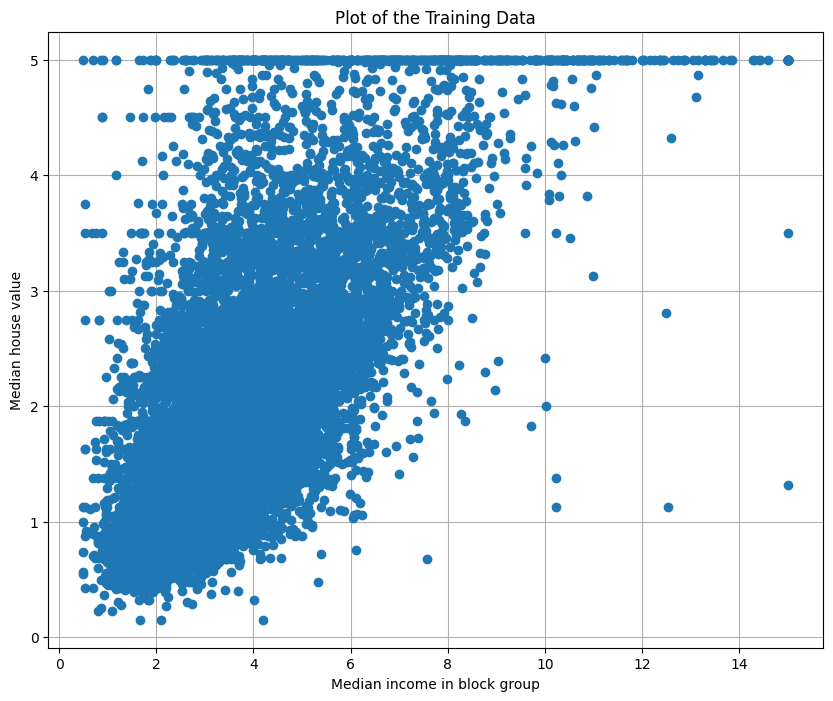

In [5]:
# You can use this function to plot the data and then add your own plots on top..
def plot_data(x, y):
    plt.figure(figsize=[10,8])
    plt.plot(x, y, 'o')
    plt.grid(True)
    plt.xlabel('Median income in block group')
    plt.ylabel('Median house value')

plot_data(x_train_unnormalised, y_train_unnormalised)
plt.title('Plot of the Training Data')

We next normalise the data such that the mean of the data is zero and it is having a specific spread around 0.
This is a good practice, particularly when we are dealing with multiple features, each having a different range of values.

Text(0.5, 1.0, 'Plot of the Training Data After Normalisation')

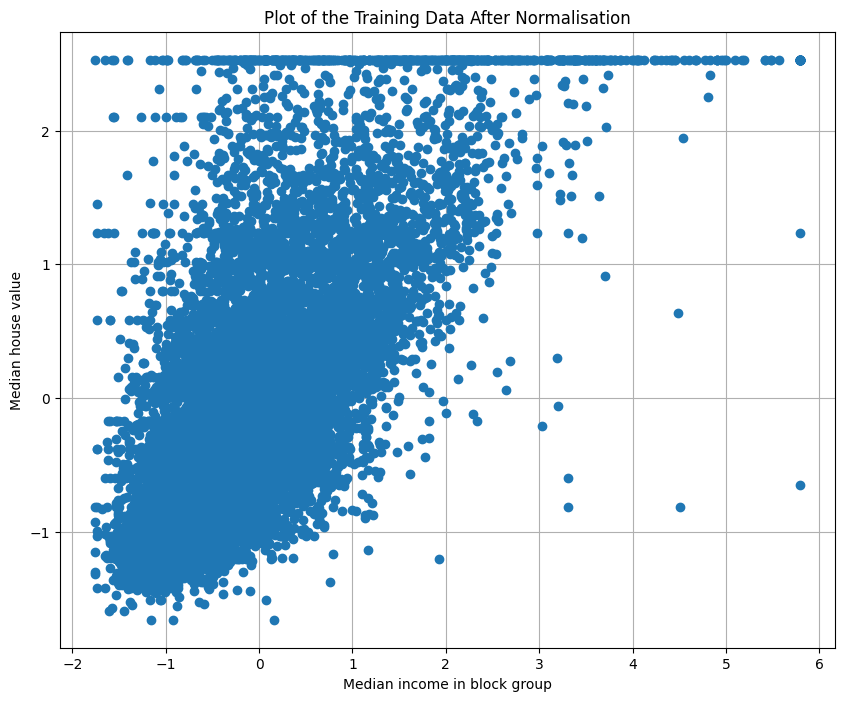

In [6]:
# compute the mean and standard deviation (std) of the attribute
xmean = x_train_unnormalised.mean()
xstd = x_train_unnormalised.std()

# use mean and std to normalise training attribute
x_train = x_train_unnormalised
x_train = (x_train-xmean)/xstd

# use mean and std to normalise testing attribute
x_test = x_test_unnormalised
x_test = (x_test- xmean)/xstd

# compute the mean and standard deviation (std) of the target
ymean = y_train_unnormalised.mean()
ystd = y_train_unnormalised.std()

# use mean and std to normalise training target
y_train = y_train_unnormalised
y_train = (y_train - ymean)/ystd

# use mean and std to normalise testing target
y_test = y_test_unnormalised
y_test = (y_test- ymean)/ystd

# plot the normalised training data
def plot_data(x, y):
    plt.figure(figsize=[10,8])
    plt.plot(x, y, 'o')
    plt.grid(True)
    plt.xlabel('Median income in block group')
    plt.ylabel('Median house value')

plot_data(x_train, y_train)
plt.title('Plot of the Training Data After Normalisation')

## Data Training

Now based on the prepared training data, we employ linear regression to fit a line $y = m * x + b$ to predict the target (median house value) from the attribute (median income).

In [7]:
# initilise the two parameters (m and b) of the linear regression model y = m * x + b
var = tf.Variable(1.) # the constructor that creates a new trainable TensorFlow variable
m = tf.Variable(1., shape=tf.TensorShape(None)) # the parameter equivalent to slope of the line
b = tf.Variable(var) # the parameter equivalent to y-intercept of the line

# return the predicted value from attribute x based on the linear regression model with m and b, i.e., y = m * x + b
# Just implementing y = m * x + b, made general enough to handle multiple features at once.
# So this function takes input(s) x and returns the model's predicted y value, using whatever m (slope) and b (intercept) currently are.
def predict(x):
    if len(x.shape)==1:
        x=tf.reshape(x,[x.shape[0],1])
        # tf.reduce_sum is TensorFlow's function for adding up numbers in a tensor — basically the TensorFlow version of Python's built-in sum(),
    return tf.reduce_sum(m * x, 1) + b

# the mean squared error (MSE) between the actual target 'y' and the predicted value 'predicted'
def mse(y, predicted):
    return tf.reduce_mean(tf.square(y-predicted))

# optimise m and b based on minimizing MSE loss using gradient descent method 
def update(X, y, learning_rate): 
    # X is capitalized by convention to indicate "this represents 
    # a matrix of inputs (samples x features)", following common 
    # ML/math notation where matrices are uppercase and vectors (y) are lowercase

    # learning_rate is a small scaling factor (commonly something like 0.01, 0.001, 0.1) that controls how big a step you take in that direction each update.

    # compute MSE loss
    # GradientTape -> tensorFlow's mechanism for automatic differentiation.
    with tf.GradientTape(persistent=True) as g:
        loss = mse(y, predict(X))
        
        #print("Loss: ", loss)

    # compute gradient based on loss
    # g is just the name given to this specific GradientTape instance 
    # gradient is a method that belongs to the GradientTape object
    # i.e. "If I change m by a tiny amount, how much does loss change, and in which direction?"
    dy_dm = g.gradient(loss, m)

    # "If I change b (the y-intercept) by a tiny amount, how much does loss change, and in which direction?"
    dy_db = g.gradient(loss, b)

    # update m and b along the negative gradient controlled by learning rate
    # assign_sub(value) is TensorFlow's equivalent of Python's -=
    # This is the step size: the gradient scaled down by the learning_rate
    m.assign_sub(learning_rate * dy_dm)
    b.assign_sub(learning_rate * dy_db)

# training process
def train(X, y, learning_rate=0.01, epochs=5):
    X = X.astype(np.float32)            # This just guarantees X matches the dtype TensorFlow expects.


#  if X is 1D (like your single-feature x_train), reshape it into a 2D column: (n_samples, 1). 
# This ensures X is always in the "samples × features" format 
    if len(X.shape)==1:
        X=tf.reshape(X,[X.shape[0],1])

# initialize m to match the number of features
# -1 just means "last axis," a Python shorthand - the number of features 
#  builds a list with var's value (1.0) repeated once per feature. m.assign(...) then sets m to that list — 
# so if you have 1 feature, m becomes [1.0]; if you had 3 features, m becomes [1.0, 1.0, 1.0].
    m.assign([var]*X.shape[-1])
    # the training loop
    # Runs update() (compute loss → compute gradients → nudge m and b) once per epoch
    # Each call slightly improves m and b based on the previous call's
    for i in range(epochs):
        #print("Epoch: ", i)
        update(X, y, learning_rate)


# This one call: converts x_train to float32, 
# reshapes it to (n_samples, 1) (since it's your single MedInc feature),
# sets m to [1.0], 
# then runs 50 rounds of gradient descent — after which m and b should hold values that approximate the best linear fit between income and house value.
train(x_train, y_train, learning_rate=0.1, epochs=50)


2026-07-02 23:33:14.981972: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5 Pro
2026-07-02 23:33:14.982004: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-07-02 23:33:14.982021: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-07-02 23:33:14.982049: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-02 23:33:14.982072: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


### Notes

#### Why does var = tf.Variable(1.) need to be a float?
- Since this variable is going to represent something like a weight or bias that gets continuously, gradually adjusted during training (e.g., 1.0 → 0.98 → 0.943 → ...)
- It absolutely needs to be a float, not an int
- Gradient descent updates values by tiny fractional amounts — if var were an int, it couldn't represent 0.943, and TensorFlow would either throw an error or behave incorrectly when trying to apply those fractional updates.

So the . isn't decorative — **it's a deliberate choice to make sure the variable starts life as a float**, matching the type of math that's about to be done to it throughout training.

#### What tf.TensorShape(None) changes?
- tf.TensorShape(None) means "unknown/unconstrained shape" — you're telling TensorFlow: "don't lock this variable's shape yet. 
- Let it be flexible so I can assign it a different-shaped value later if I need to."
So:
```python
m = tf.Variable(1., shape=tf.TensorShape(None))
```
- starts `m` off as a scalar `(1.0)`, but explicitly leaves the door open to later do something like:

```python
m.assign([1.0, 2.0, 3.0])   # reshape to a vector — allowed because shape wasn't locked
```
- Without the shape=tf.TensorShape(None) part, that .assign(...) call with a different shape would throw an error, because the variable's shape was fixed to () at creation.

#### Why are m and b written differently?

Bottom line: don't read too much into m vs b using different syntax — it's not signaling anything different about their roles. Both are trainable scalars starting at 1.0. The one line worth paying attention to is m's shape=tf.TensorShape(None), since that's the part that actually matters for what happens to m later in the train() function.

#### why we need the reshape check?
- predict() is written expecting x to be shape (n_samples, n_features). 
- If you only have 1 feature (like MedInc), reshaping to (n_samples, 1) puts your data into that same 2D convention (n samples, 1 feature), 
- so the multiplication with m later in the function works consistently regardless of whether you're using 1 feature or several.

#### what is learning rate?

So learning_rate is a small scaling factor (commonly something like 0.01, 0.001, 0.1) that controls how big a step you take in that direction each update.
Think of it like walking downhill blindfolded, trying to find the lowest point of a valley (minimizing loss):

Too large a learning rate (e.g., 1.0 or 10) → you take huge leaps, might overshoot the bottom of the valley entirely and bounce around chaotically, never converging (loss might even blow up / become NaN).


Too small a learning rate (e.g., 0.00001) → you take tiny, cautious steps, technically move toward the minimum, but so slowly that training takes forever (or gets stuck before reaching a good solution within your epoch budget).


Well-chosen learning rate → steady, efficient progress toward the minimum.

## Data Testing and Linear Model Visualisation

Finally, based on the linear regression result, we analyse and visualise the house value prediction model by computing the predicting error and ploting the result using the test data.

In [8]:
# predict house value using the fitted model y = m * x + b on the test set
x_test = x_test.astype(np.float32)
# using our updated m and b
pred = predict(x_test)
# de-normalise the predicted value
pred *= ystd
pred += ymean

In [9]:
# de-normalise the actual house value on the test set (gold data)
y_test = y_test*ystd
y_test += ymean
# compute the mean squared error
error = mse(pred,y_test)
print(error)

tf.Tensor(0.6813539, shape=(), dtype=float32)


#### What the number itself tells you:
`MSE = 0.6813539` is the average of the squared differences between your model's predicted house values and the actual house values, across all test samples — computed in units of $100,000² (since that's the dataset's target scale).


Taking the square root to make it interpretable: RMSE ≈ 0.825, meaning on average, your model's predictions are off from the real house value by about $82,500.

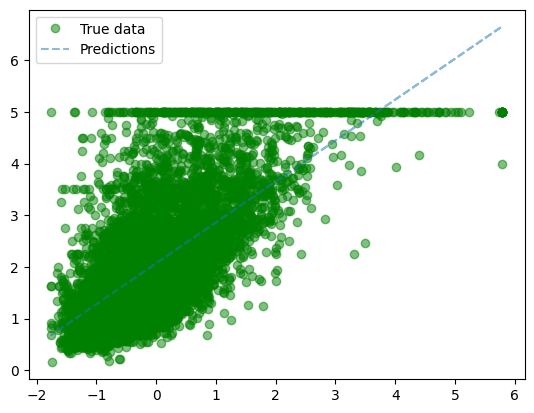

In [10]:
# plot the test data and the linear model y = m * x + b
plt.clf()
plt.plot(x_test, y_test, 'go', label='True data', alpha=0.5)
plt.plot(x_test, pred, '--', label='Predictions', alpha=0.5)
plt.legend(loc='best')
plt.show()
